In [13]:
from geometries_kolmo import uniform_field_kolmo, wavy_field_kolmo, helical_field_kolmo, hourglass_field_kolmo
import matplotlib.pyplot as plt
import numpy as np

## Compare Helical

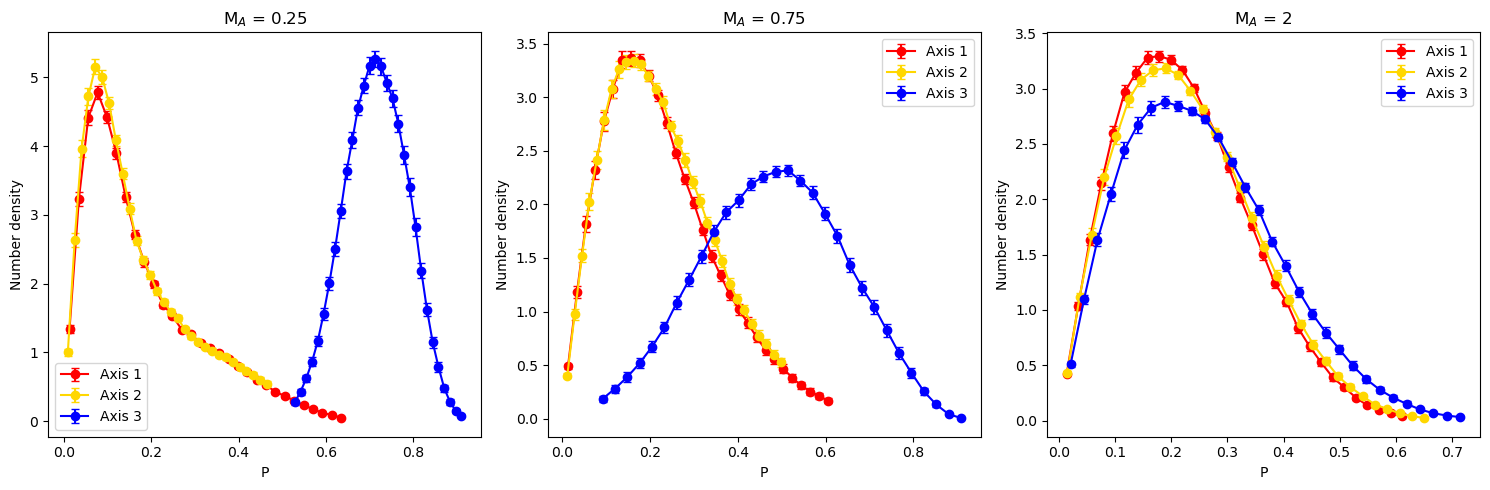

In [10]:
gsize = 64
nbins = 30
nruns = 100
colors = ['red', 'gold','blue']
mach_numbers = [0.25, 0.75, 2]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for iax in range(3):
    for j, Mval in enumerate(mach_numbers):

        ax           = axes[j]
        all_hists    = []
        P0, PHI, COS = helical_field_kolmo(M_A=Mval, alpha=np.pi/6, iaxis=iax, g_size=gsize, plotting=False)
        bin_edges    = np.histogram_bin_edges(P0.flatten(), bins=nbins)

        for i in range(nruns):
            P, PHI, COS = helical_field_kolmo(M_A=Mval, alpha=np.pi/6, iaxis=iax, g_size=gsize, plotting=False)
            hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
            all_hists.append(hist)

        all_hists = np.array(all_hists)
        mean_hist = np.mean(all_hists, axis=0)
        std_hist  = np.std(all_hists, axis=0)
        sem_hist  = std_hist / np.sqrt(nruns)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        ax.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color=colors[iax], label=f"Axis {iax+1}")
        ax.set_xlabel("P")
        ax.set_ylabel("Number density")
        ax.set_title(f"M$_A$ = {Mval}")
        ax.legend()

plt.tight_layout()
plt.show()

## Compare Hourglass

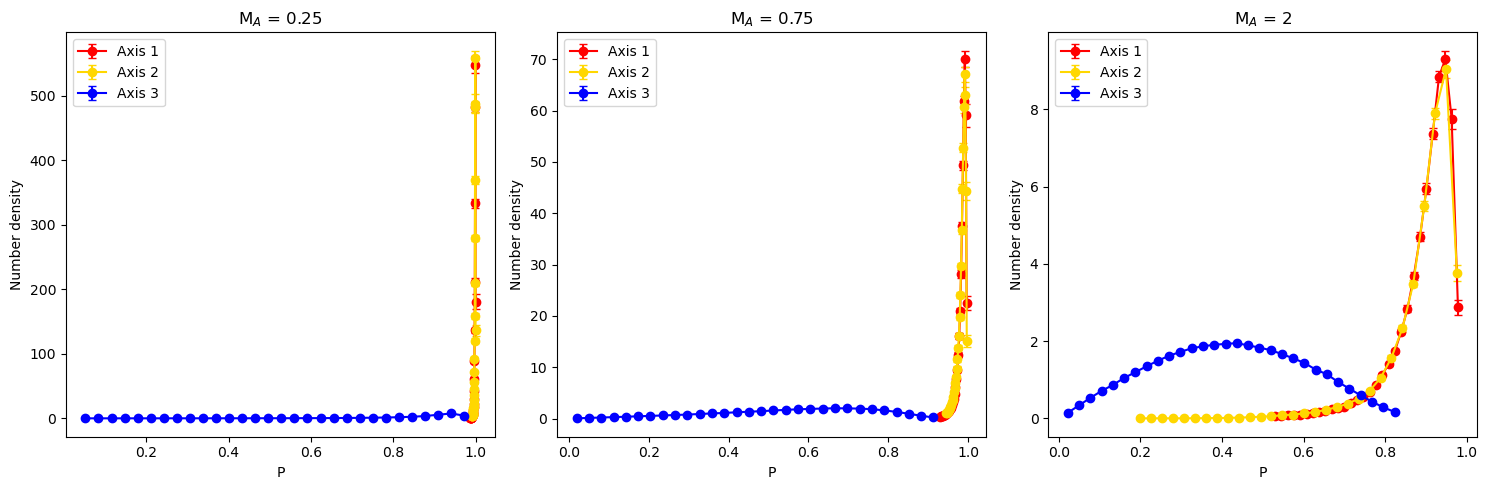

In [16]:
gsize = 64
nbins = 30
nruns = 100
colors = ['red', 'gold','blue']
mach_numbers = [0.25, 0.75, 2]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for iax in range(3):
    for j, Mval in enumerate(mach_numbers):

        ax           = axes[j]
        all_hists    = []
        P0, PHI, COS = hourglass_field_kolmo(M_A=Mval, g_size=gsize, iaxis=iax, plotting=False)
        bin_edges    = np.histogram_bin_edges(P0.flatten(), bins=nbins)

        for i in range(nruns):
            P, PHI, COS = hourglass_field_kolmo(M_A=Mval, g_size=gsize, iaxis=iax, plotting=False)
            hist, _ = np.histogram(P.flatten(), bins=bin_edges, density=True)
            all_hists.append(hist)

        all_hists = np.array(all_hists)
        mean_hist = np.mean(all_hists, axis=0)
        std_hist  = np.std(all_hists, axis=0)
        sem_hist  = std_hist / np.sqrt(nruns)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        ax.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color=colors[iax], label=f"Axis {iax+1}")
        ax.set_xlabel("P")
        ax.set_ylabel("Number density")
        ax.set_title(f"M$_A$ = {Mval}")
        ax.legend()

plt.tight_layout()
plt.show()

/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


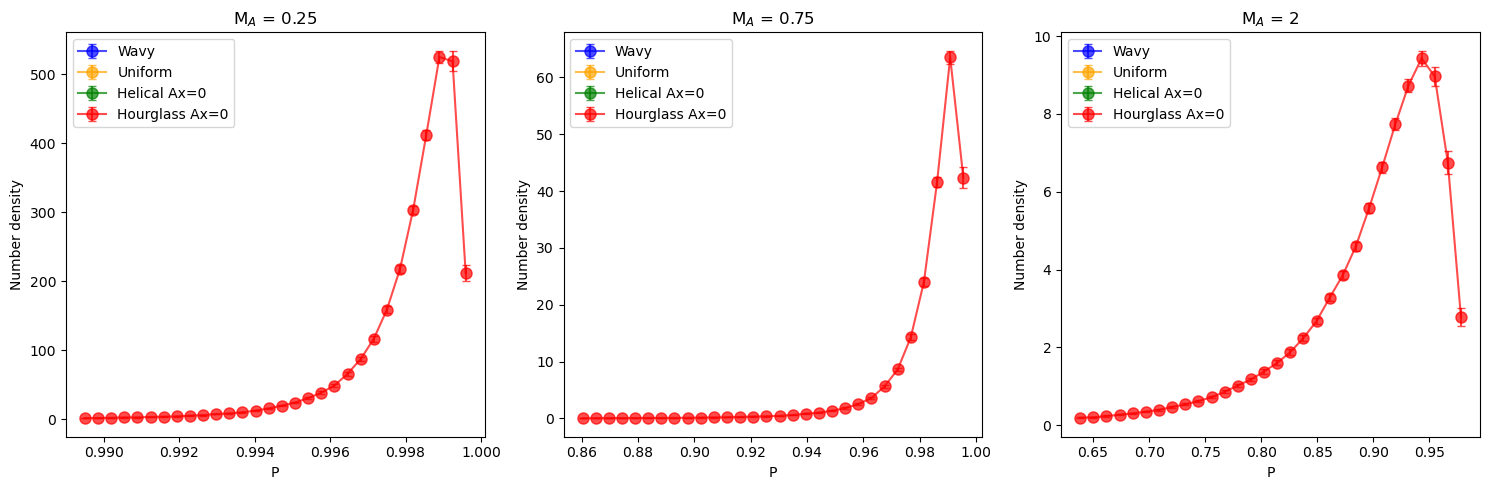

In [29]:


# wavy_field_kolmo(M_A, Bz_true, amplitude_range, g_size, plotting=False)
# uniform_field_kolmo(M_A, Bz_true, angle_range, g_size, plotting=False)

gsize = 64
nbins = 30
nruns = 100
colors = ['red', 'gold','blue']
mach_numbers = [0.25, 0.75, 2]


fig, axes = plt.subplots(1, 3, figsize=(15,5))

for j, Mval in enumerate(mach_numbers):

    ax           = axes[j]

    W_hists    = []
    U_hists    = []
    He_hists   = []
    H_hists    = []

    # P_W, _, _ = wavy_field_kolmo(M_A=Mval, Bz_true=0, amplitude_range=[0,1], g_size=gsize, plotting=False)
    P_H, PHI_H, COS_H    = hourglass_field_kolmo(M_A=Mval, g_size=gsize, iaxis=0, plotting=False)
    # P_He, _, _ = helical_field_kolmo(M_A=Mval, alpha=0, iaxis=0, g_size=gsize, plotting=False)
    bin_edges    = np.histogram_bin_edges(P_H.flatten(), bins=nbins)

    for i in range(nruns):

        P_W, PHI_W, COS_W    = wavy_field_kolmo(M_A=Mval, Bz_true=0, amplitude_range=[0,1], g_size=gsize, plotting=False)
        P_U, PHI_U, COS_U    = uniform_field_kolmo(M_A=Mval, Bz_true=0, angle_range=[0,np.pi/4], g_size=gsize, plotting=False)
        P_He, PHI_He, COS_He = helical_field_kolmo(M_A=Mval, alpha=0, iaxis=0, g_size=gsize, plotting=False)
        P_H, PHI_H, COS_H    = hourglass_field_kolmo(M_A=Mval, g_size=gsize, iaxis=0, plotting=False)

        Whist, _  = np.histogram(P_W.flatten(), bins=bin_edges, density=True)
        Uhist, _  = np.histogram(P_U.flatten(), bins=bin_edges, density=True)
        Hehist, _ = np.histogram(P_He.flatten(), bins=bin_edges, density=True)
        Hhist, _  = np.histogram(P_H.flatten(), bins=bin_edges, density=True)

        W_hists.append(Whist)
        U_hists.append(Uhist)
        He_hists.append(Hehist)
        H_hists.append(Hhist)

    W_hists = np.array(W_hists)
    U_hists = np.array(U_hists)
    He_hists = np.array(He_hists)
    H_hists = np.array(H_hists)

    W_mean_hist = np.mean(W_hists, axis=0)
    W_std_hist  = np.std(W_hists, axis=0)
    W_sem_hist  = W_std_hist / np.sqrt(nruns)

    U_mean_hist = np.mean(U_hists, axis=0)
    U_std_hist  = np.std(U_hists, axis=0)
    U_sem_hist  = U_std_hist / np.sqrt(nruns)

    He_mean_hist = np.mean(He_hists, axis=0)
    He_std_hist  = np.std(He_hists, axis=0)
    He_sem_hist  = He_std_hist / np.sqrt(nruns)

    H_mean_hist = np.mean(H_hists, axis=0)
    H_std_hist  = np.std(H_hists, axis=0)
    H_sem_hist  = H_std_hist / np.sqrt(nruns)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # plt.errorbar(bin_centers, mean_hist, yerr=sem_hist, fmt='o-', capsize=3, color=colors[iax], label=f"Axis {iax+1}")
    ax.errorbar(bin_centers, W_mean_hist, yerr=W_sem_hist, fmt='o-', capsize=3, markersize = 8, color='blue', label="Wavy", alpha=0.7)
    ax.errorbar(bin_centers, U_mean_hist, yerr=U_sem_hist, fmt='o-', capsize=3, markersize = 8, color='orange', label="Uniform", alpha=0.7)
    ax.errorbar(bin_centers, He_mean_hist, yerr=He_sem_hist, fmt='o-', capsize=3, markersize = 8, color='green', label="Helical Ax=0", alpha=0.7)
    ax.errorbar(bin_centers, H_mean_hist, yerr=H_sem_hist, fmt='o-', capsize=3, markersize = 8, color='red', label="Hourglass Ax=0", alpha=0.7)
    
    ax.set_xlabel("P")
    ax.set_ylabel("Number density")
    ax.set_title(f"M$_A$ = {Mval}")
    ax.legend()

plt.tight_layout()
plt.show()

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
